In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_absolute_error,mean_squared_error
sys.path.append(os.path.abspath(".."))

from src.preprocessing import load_and_clean_data
from src.feature_engineering import create_features
from src.split import train_test_split
from src.train import walk_forward_validation, train_models
from src.forecast import multi_step_forecast

# Loading data

In [2]:
df=load_and_clean_data()

# Feature Engineering

In [3]:
df=create_features(df)

# EDA

## Daily Returns

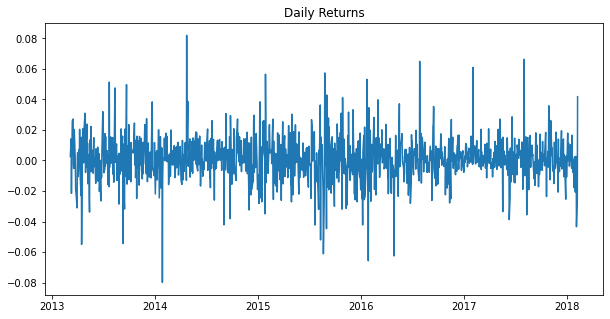

In [4]:
plt.figure(figsize=(10,5))
plt.plot(df['returns'])
plt.title("Daily Returns")
plt.show()

## Moving Average

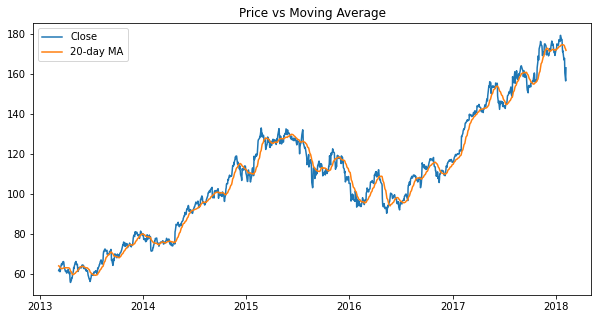

In [5]:
plt.figure(figsize=(10,5))
plt.plot(df['close'],label='Close')
plt.plot(df['ma_20'],label='20-day MA')
plt.legend()
plt.title("Price vs Moving Average")
plt.show()

## Volume Analysis

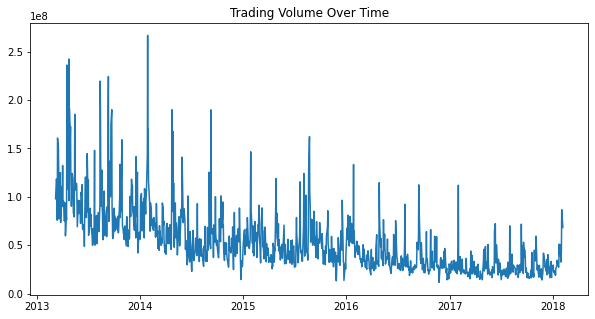

In [6]:
plt.figure(figsize=(10,5))
plt.plot(df['volume'])
plt.title("Trading Volume Over Time")
plt.show()

## Distribution of Returns

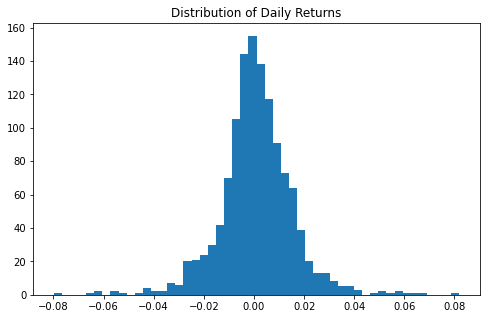

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df['returns'].dropna(), bins=50)
plt.title("Distribution of Daily Returns")
plt.show()

## Correlation

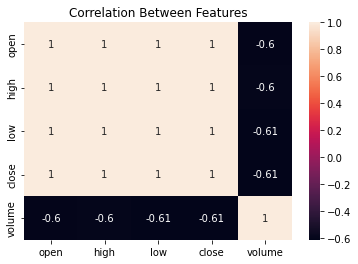

In [8]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['open','high','low','close','volume']].corr(), annot=True)
plt.title("Correlation Between Features")
plt.show()

## Insights

*Stock price shows an overall upward trend over time

*Daily returns fluctuate around zero with occasional spikes

*Moving average clearly smooths price trend

*Volume spikes indicate high trading activity periods

*Price features (open, high, low, close) are strongly correlated

# Loading training and testing data

In [9]:
xtrain, xtest, ytrain, ytest=train_test_split(df)

# Model Building

In [10]:
lr,xgb=train_models(xtrain,ytrain)

# Model Metrics

## 1.Linear Regression

In [11]:
ypred_lr=lr.predict(xtest)

mae_lr=mean_absolute_error(ytest,ypred_lr)
rmse_lr=np.sqrt(mean_squared_error(ytest,ypred_lr))

print('MAE:',mae_lr)
print('RMSE:',rmse_lr)

MAE: 0.008731767364987436
RMSE: 0.012343708003415202


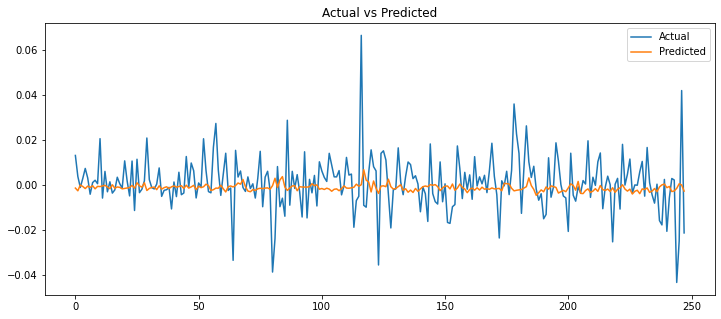

In [12]:
plt.figure(figsize=(12,5))

plt.plot(ytest.values,label='Actual')
plt.plot(ypred_lr,label='Predicted')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()

## 2.XGBoost Regression

In [13]:
ypred_xgb=xgb.predict(xtest)

mae_xgb=mean_absolute_error(ytest,ypred_xgb)
rmse_xgb=np.sqrt(mean_squared_error(ytest,ypred_xgb))

print('MAE:',mae_xgb)
print('RMSE:',rmse_xgb)

MAE: 0.010355989279603942
RMSE: 0.014343803702053157


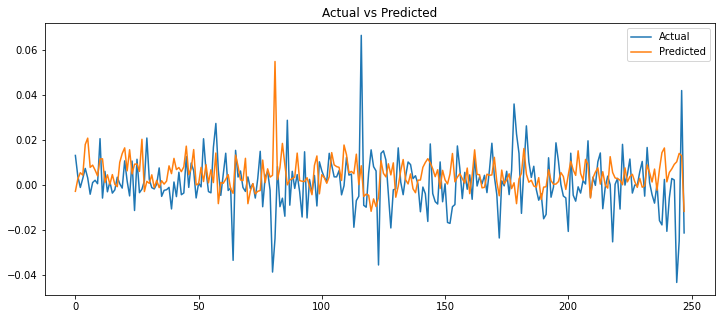

In [14]:
plt.figure(figsize=(12,5))

plt.plot(ytest.values,label='Actual')
plt.plot(ypred_xgb,label='Predicted')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()

<Figure size 1080x720 with 0 Axes>

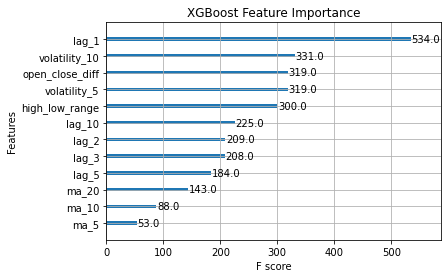

In [15]:
from xgboost import  plot_importance

plt.figure(figsize=(15,10))
plot_importance(xgb)
plt.title("XGBoost Feature Importance")
plt.show()

In [16]:
importance=xgb.feature_importances_

feature_importance=pd.DataFrame({
    'Features':xtrain.columns,
    'Importance':importance
}).sort_values(by='Importance',ascending=False)

feature_importance

,Features,Importance
3,lag_5,0.110219
9,volatility_10,0.099131
7,ma_20,0.089434
4,lag_10,0.089192
8,volatility_5,0.087243
10,high_low_range,0.084925
11,open_close_diff,0.083213
1,lag_2,0.080407
6,ma_10,0.079801
5,ma_5,0.074678


## 3.Model Comparision

Observations:

Linear Regression slightly outperforms XGBoost in both MAE and RMSE.
Both models perform similarly, indicating that the signal in the data is mostly linear.
XGBoost does not provide significant improvement, likely due to weak nonlinear patterns in the dataset.

Conclusion:

For this dataset, simpler linear relationships are sufficient to capture most of the predictive signal. More complex models like XGBoost do not significantly improve performance in this case.

In [17]:
results=pd.DataFrame({
    'Model':['Linear Regression','XGBoost'],
    "MAE": [mae_lr, mae_xgb],
    "RMSE": [rmse_lr, rmse_xgb]
})
results

,Model,MAE,RMSE
0,Linear Regression,0.008732,0.012344
1,XGBoost,0.010356,0.014344


# Walk Forward Validation

In [18]:
train_size=int(len(df)*0.6)
test_size=int(len(df)*0.2)

features = [
    'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10',
    'ma_5', 'ma_10', 'ma_20',
    'volatility_5', 'volatility_10',
    'high_low_range', 'open_close_diff'
]


result=walk_forward_validation(df,features,train_size,test_size)

lr_errors=result['lr_errors']
xgb_errors=result['xgb_errors']
lr_preds=result['lr_preds']
xgb_preds=result['xgb_preds']
actual=result['actuals']

pred_df=pd.DataFrame({
    'lr_preds':lr_preds,
    'xgb_preds':xgb_preds,
    'actuals':actual
})

pred_df

,lr_preds,xgb_preds,actuals
0,0.000849,-0.005241,0.008746
1,0.000092,-0.014574,-0.022605
2,0.002103,-0.006141,0.014891
3,0.000361,-0.001519,0.006868
4,-0.000670,-0.008324,0.001550
...,...,...,...
489,-0.000833,0.007638,-0.005894
490,-0.003093,-0.000282,0.002755
491,-0.002794,0.000452,0.002090
492,-0.001609,0.000054,-0.043390


# Multi Step Forescasting

In [19]:
last_data=xtest.iloc[-1].copy()

## 1.Using LR

In [20]:
multi_step_forecast(lr,last_data,10,features)

[-0.002837397748246516,
 0.18571571654450147,
 0.25765216929983126,
 0.39199948158255793,
 0.39165084064471817,
 0.3915304256893854,
 0.39141523972768394,
 0.3914157251508122,
 0.39141587866489513,
 0.3914159772825214]

## 2.Using XGB

In [21]:
multi_step_forecast(xgb,last_data,10,features)

[-0.011823002,
 -0.008311691,
 -0.0021763681,
 0.00054769666,
 0.00054769666,
 0.00054769666,
 0.00054769666,
 0.00054769666,
 0.00054769666,
 0.00054769666]

# Error Analysis

In [22]:
xgb_errors = ytest.values - ypred_xgb
lr_errors = ytest.values - ypred_lr

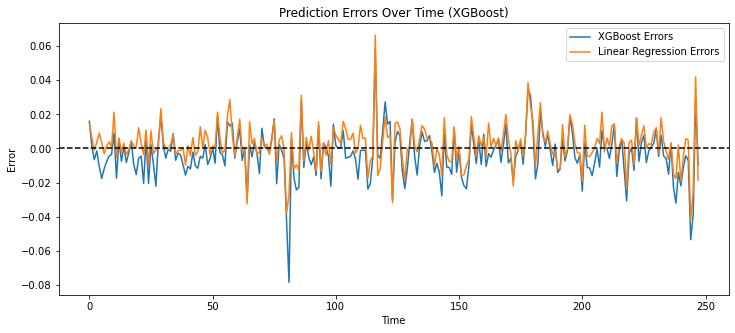

In [23]:
plt.figure(figsize=(12,5))
plt.plot(xgb_errors,label='XGBoost Errors')
plt.plot(lr_errors,label='Linear Regression Errors')
plt.axhline(0, color='black', linestyle='--')
plt.title("Prediction Errors Over Time (XGBoost)")
plt.xlabel("Time")
plt.ylabel("Error")
plt.legend()
plt.show()

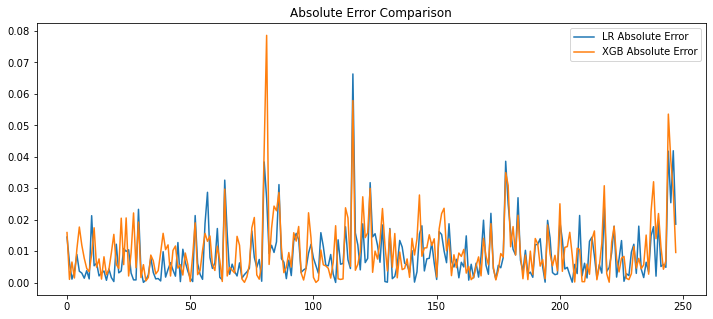

In [24]:
abs_lr = np.abs(lr_errors)
abs_xgb = np.abs(xgb_errors)

plt.figure(figsize=(12,5))
plt.plot(abs_lr, label="LR Absolute Error")
plt.plot(abs_xgb, label="XGB Absolute Error")
plt.legend()
plt.title("Absolute Error Comparison")
plt.show()

In [25]:
print("LR MAE:", np.mean(abs_lr))
print("XGB MAE:", np.mean(abs_xgb))

LR MAE: 0.008731767364987436
XGB MAE: 0.010355989279603942


In [26]:
pred_df.describe()

,lr_preds,xgb_preds,actuals
count,494.000000,494.000000,494.000000
mean,-0.000858,0.001078,0.001065
std,0.001520,0.007973,0.012348
min,-0.004920,-0.036780,-0.062578
25%,-0.001816,-0.003208,-0.004627
50%,-0.000942,0.000108,0.000647
75%,-0.000076,0.005195,0.007161
max,0.006621,0.045804,0.066295


In [27]:
pred_df[['actuals', 'lr_preds']].corr()

,actuals,lr_preds
actuals,1.000000,0.000492
lr_preds,0.000492,1.000000


In [28]:
pred_df[['actuals', 'xgb_preds']].corr()

,actuals,xgb_preds
actuals,1.000000,-0.058868
xgb_preds,-0.058868,1.000000
